<a href="https://colab.research.google.com/github/202201373/Ass_6_MLOPs/blob/main/DSAI_490_ASS_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. **Setup & Imports**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

##2. **Data Loading & Preprocessing**

In [ ]:
from google.colab import drive
import os
import shutil
import kagglehub

drive.mount('/content/drive')

print("Downloading dataset from Kaggle...")
os.environ["KAGGLEHUB_VERIFY_SSL"] = "0"
temp_path = kagglehub.dataset_download("andrewmvd/medical-mnist")
print("Downloaded to temporary path:", temp_path)

DRIVE_DATA_DIR = '/content/drive/MyDrive/medical-mnist'

if not os.path.exists(DRIVE_DATA_DIR):
    print(f"Moving dataset to Google Drive: {DRIVE_DATA_DIR}...")
    shutil.copytree(temp_path, DRIVE_DATA_DIR)
    print("Dataset successfully uploaded to Google Drive.")
else:
    print(f"Dataset already exists in Google Drive at {DRIVE_DATA_DIR}.")

!pip install tensorflow matplotlib numpy seaborn scikit-learn

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using Colab cache for faster access to the 'medical-mnist' dataset.
Downloaded to temporary path: /kaggle/input/medical-mnist
Dataset already exists in Google Drive at /content/drive/MyDrive/medical-mnist.


In [ ]:
DATA_DIR = "/content/drive/MyDrive/medical-mnist"
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

##3. **Build tf.data Pipelines**

In [ ]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

def load_raw_dataset(data_dir):
    return tf.keras.preprocessing.image_dataset_from_directory(
        data_dir,
        image_size=IMG_SIZE,
        batch_size=None,
        shuffle=True
    )

In [ ]:
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, image

In [ ]:
def build_pipeline(data_dir):
    dataset = load_raw_dataset(data_dir)

    dataset = dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.shuffle(1000)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [ ]:
train_ds = build_pipeline(DATA_DIR)

Found 30121 files belonging to 4 classes.


In [ ]:
for images, targets in train_ds.take(1):
    print(images.shape)

(32, 64, 64, 3)


##4. **AUTOENCODER (AE)**

**4.1 Model Architecture**

In [ ]:
LATENT_DIM = 64

# Encoder
def build_encoder():
    inputs = layers.Input(shape=(64, 64, 3))
    x = layers.Conv2D(32, 3, strides=2, activation='relu', padding='same')(inputs)
    x = layers.Conv2D(64, 3, strides=2, activation='relu', padding='same')(x)
    x = layers.Flatten()(x)
    latent = layers.Dense(LATENT_DIM)(x)
    return Model(inputs, latent, name="encoder")

# Decoder
def build_decoder():
    inputs = layers.Input(shape=(LATENT_DIM,))
    x = layers.Dense(16*16*64, activation='relu')(inputs)
    x = layers.Reshape((16, 16, 64))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(x)
    outputs = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(x)
    return Model(inputs, outputs, name="decoder")

# AE Model
class Autoencoder(Model):
    def __init__(self):
        super().__init__()
        self.encoder = build_encoder()
        self.decoder = build_decoder()

    def call(self, x):
        z = self.encoder(x)
        return self.decoder(z)

**4.2 Train AE**

In [ ]:
ae = Autoencoder()
ae.compile(optimizer='adam', loss='mse')

history_ae = ae.fit(train_ds, epochs=10)

Epoch 1/10
942/942 ━━━━━━━━━━━━━━━━━━━━ 144s 13ms/step - loss: 0.0142
Epoch 2/10
942/942 ━━━━━━━━━━━━━━━━━━━━ 113s 10ms/step - loss: 0.0052
Epoch 3/10
942/942 ━━━━━━━━━━━━━━━━━━━━ 142s 9ms/step - loss: 0.0040
Epoch 4/10
942/942 ━━━━━━━━━━━━━━━━━━━━ 94s 8ms/step - loss: 0.0036
Epoch 5/10
942/942 ━━━━━━━━━━━━━━━━━━━━ 103s 10ms/step - loss: 0.0033
Epoch 6/10
942/942 ━━━━━━━━━━━━━━━━━━━━ 92s 9ms/step - loss: 0.0030
Epoch 7/10
942/942 ━━━━━━━━━━━━━━━━━━━━ 90s 10ms/step - loss: 0.0029
Epoch 8/10
942/942 ━━━━━━━━━━━━━━━━━━━━ 90s 9ms/step - loss: 0.0027
Epoch 9/10
942/942 ━━━━━━━━━━━━━━━━━━━━ 90s 9ms/step - loss: 0.0026
Epoch 10/10
942/942 ━━━━━━━━━━━━━━━━━━━━ 91s 9ms/step - loss: 0.0025


**4.3 Reconstruction Visualization**

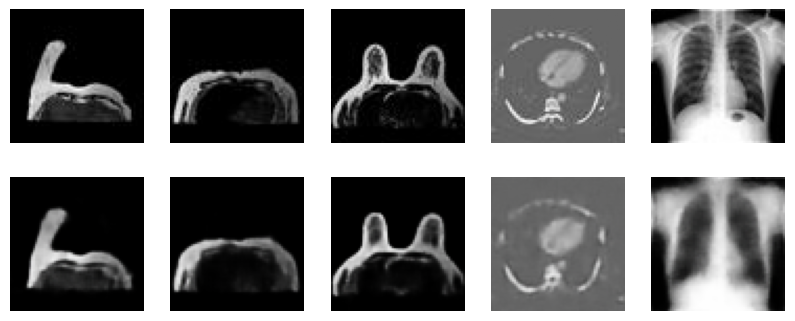

In [ ]:
def show_reconstruction(model, dataset):
    for x, _ in dataset.take(1):
        recon = model(x)

        plt.figure(figsize=(10, 4))
        for i in range(5):
            # original
            plt.subplot(2, 5, i+1)
            plt.imshow(x[i])
            plt.axis("off")

            # reconstructed
            plt.subplot(2, 5, i+6)
            plt.imshow(recon[i])
            plt.axis("off")
        plt.show()

show_reconstruction(ae, train_ds)

##5. **VARIATIONAL AUTOENCODER (VAE)**

In [ ]:
class VAE(Model):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = tf.keras.Sequential([
            layers.InputLayer(input_shape=(64,64,3)),
            layers.Conv2D(32, 3, strides=2, activation='relu'),
            layers.Conv2D(64, 3, strides=2, activation='relu'),
            layers.Flatten(),
            layers.Dense(128, activation='relu'),
            layers.Dense(latent_dim * 2)
        ])

        self.decoder = build_decoder()

    def sample(self, mu, log_var):
        eps = tf.random.normal(shape=tf.shape(mu))
        return mu + tf.exp(0.5 * log_var) * eps

    def call(self, x):
        encoded = self.encoder(x)
        mu, log_var = tf.split(encoded, num_or_size_splits=2, axis=1)
        z = self.sample(mu, log_var)
        x_recon = self.decoder(z)
        return x_recon, mu, log_var

**5.1 VAE Loss**

In [ ]:
def compute_vae_loss(x, x_recon, mu, log_var):
    recon_loss = tf.reduce_mean(tf.square(x - x_recon))
    kl_loss = -0.5 * tf.reduce_mean(1 + log_var - tf.square(mu) - tf.exp(log_var))
    return recon_loss + kl_loss

**5.2 Train VAE**

In [ ]:
vae = VAE(LATENT_DIM)
optimizer = tf.keras.optimizers.Adam()

EPOCHS = 10

# store losses
total_losses = []
recon_losses = []
kl_losses = []

for epoch in range(EPOCHS):
    epoch_total = []
    epoch_recon = []
    epoch_kl = []

    for x, _ in train_ds:
        with tf.GradientTape() as tape:
            x_recon, mu, log_var = vae(x)

            # losses
            recon_loss = tf.reduce_mean(tf.square(x - x_recon))
            kl_loss = -0.5 * tf.reduce_mean(
                1 + log_var - tf.square(mu) - tf.exp(log_var)
            )
            loss = recon_loss + kl_loss

        grads = tape.gradient(loss, vae.trainable_variables)
        optimizer.apply_gradients(zip(grads, vae.trainable_variables))

        # collect batch losses
        epoch_total.append(loss.numpy())
        epoch_recon.append(recon_loss.numpy())
        epoch_kl.append(kl_loss.numpy())

    # store epoch averages
    total_losses.append(np.mean(epoch_total))
    recon_losses.append(np.mean(epoch_recon))
    kl_losses.append(np.mean(epoch_kl))

    print(f"Epoch {epoch+1}: Total={total_losses[-1]:.4f}, Recon={recon_losses[-1]:.4f}, KL={kl_losses[-1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1: Total=0.0602, Recon=0.0531, KL=0.0072
Epoch 2: Total=0.0577, Recon=0.0487, KL=0.0091
Epoch 3: Total=0.0542, Recon=0.0428, KL=0.0115
Epoch 4: Total=0.0533, Recon=0.0413, KL=0.0120
Epoch 5: Total=0.0527, Recon=0.0404, KL=0.0123
Epoch 6: Total=0.0518, Recon=0.0388, KL=0.0131
Epoch 7: Total=0.0506, Recon=0.0367, KL=0.0140
Epoch 8: Total=0.0500, Recon=0.0355, KL=0.0145
Epoch 9: Total=0.0499, Recon=0.0349, KL=0.0150
Epoch 10: Total=0.0497, Recon=0.0347, KL=0.0150


**5.3 Plot Losses**

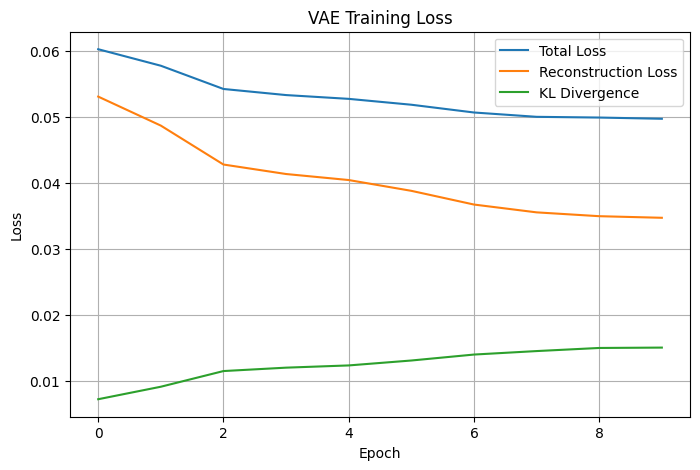

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(total_losses, label="Total Loss")
plt.plot(recon_losses, label="Reconstruction Loss")
plt.plot(kl_losses, label="KL Divergence")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")
plt.legend()
plt.grid()

plt.show()

**5.4 VAE Reconstruction Visualization**

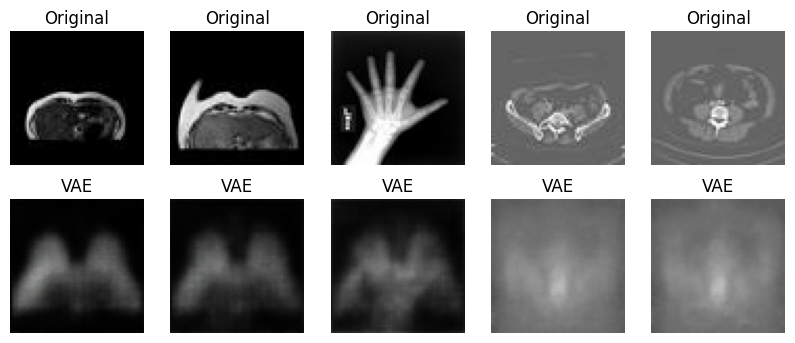

In [ ]:
def show_vae_reconstruction(model, dataset):
    for x, _ in dataset.take(1):
        x_recon, _, _ = model(x)

        plt.figure(figsize=(10,4))
        for i in range(5):
            # original
            plt.subplot(2, 5, i+1)
            plt.imshow(x[i])
            plt.title("Original")
            plt.axis("off")

            # reconstructed
            plt.subplot(2, 5, i+6)
            plt.imshow(x_recon[i])
            plt.title("VAE")
            plt.axis("off")

        plt.show()

show_vae_reconstruction(vae, train_ds)

##6. **VAE Sample Generation**

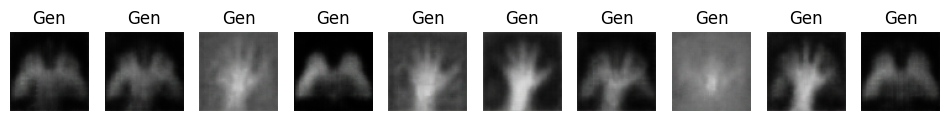

In [ ]:
def generate_vae_samples(model, num=10):
    z = tf.random.normal((num, LATENT_DIM))
    images = model.decoder(z)

    plt.figure(figsize=(12,2))
    for i in range(num):
        plt.subplot(1, num, i+1)
        plt.imshow(images[i])
        plt.title("Gen")
        plt.axis("off")

    plt.show()

generate_vae_samples(vae)

##7. **VAE Latent Space Visualization**

Found 30121 files belonging to 4 classes.


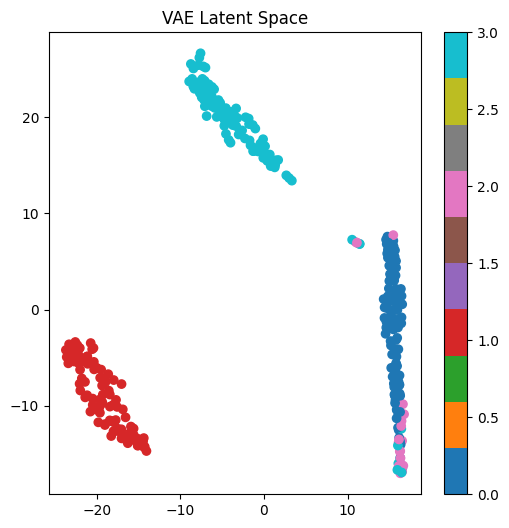

In [ ]:
def visualize_vae_latent(model, dataset):
    def load_raw_dataset_for_viz(data_dir):
        return tf.keras.preprocessing.image_dataset_from_directory(
            data_dir,
            image_size=IMG_SIZE,
            batch_size=None,
            shuffle=True
        )

    def preprocess_for_viz(image, label):
        image = tf.cast(image, tf.float32) / 255.0
        return image, label


    viz_ds = load_raw_dataset_for_viz(DATA_DIR)
    viz_ds = viz_ds.map(preprocess_for_viz, num_parallel_calls=tf.data.AUTOTUNE)
    viz_ds = viz_ds.batch(BATCH_SIZE)
    viz_ds = viz_ds.prefetch(tf.data.AUTOTUNE)

    zs = []
    labels = []

    for x, y_label in viz_ds.take(10):
        encoded = model.encoder(x)
        mu, _ = tf.split(encoded, 2, axis=1)

        zs.append(mu.numpy())
        labels.append(y_label.numpy())

    zs = np.concatenate(zs)
    labels = np.concatenate(labels)

    tsne = TSNE(n_components=2, random_state=42)
    z_2d = tsne.fit_transform(zs)

    plt.figure(figsize=(6,6))
    plt.scatter(z_2d[:,0], z_2d[:,1], c=labels, cmap='tab10')
    plt.colorbar()
    plt.title("VAE Latent Space")
    plt.show()

visualize_vae_latent(vae, train_ds)

##8. **DENOISING AUTOENCODER**

In [ ]:
def add_noise(x):
    noise = tf.random.normal(shape=tf.shape(x), stddev=0.1)
    return tf.clip_by_value(x + noise, 0.0, 1.0)

noisy_ds = train_ds.map(lambda x, y: (add_noise(x), x))

ae.fit(noisy_ds, epochs=5)

Epoch 1/5
942/942 ━━━━━━━━━━━━━━━━━━━━ 142s 13ms/step - loss: 0.0026
Epoch 2/5
942/942 ━━━━━━━━━━━━━━━━━━━━ 112s 16ms/step - loss: 0.0025
Epoch 3/5
942/942 ━━━━━━━━━━━━━━━━━━━━ 110s 13ms/step - loss: 0.0025
Epoch 4/5
942/942 ━━━━━━━━━━━━━━━━━━━━ 103s 13ms/step - loss: 0.0024
Epoch 5/5
942/942 ━━━━━━━━━━━━━━━━━━━━ 103s 13ms/step - loss: 0.0024


##9. **LOSS VISUALIZATION**

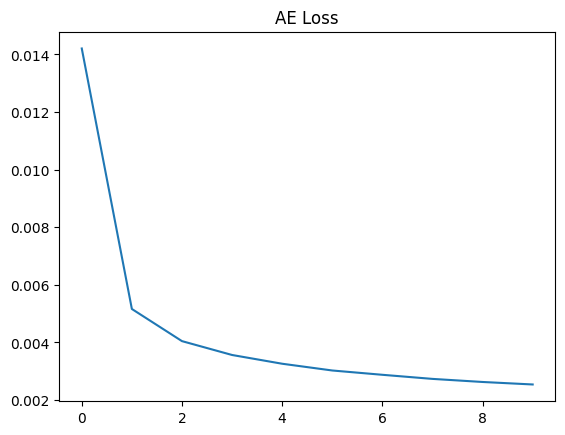

In [ ]:
plt.plot(history_ae.history['loss'])
plt.title("AE Loss")
plt.show()

##10. **VISUAL COMPARISON**

**10.1 Reconstruction Comparison**

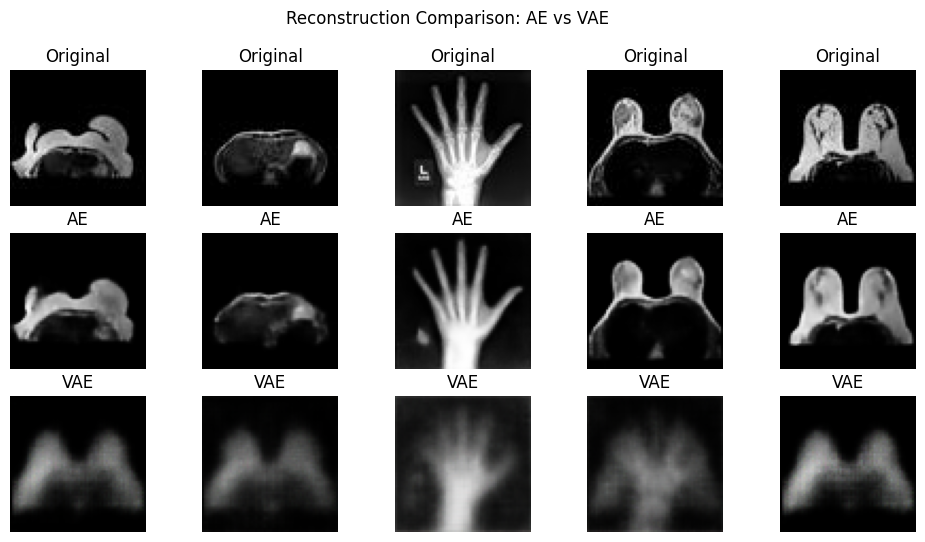

In [ ]:
def compare_reconstruction(ae, vae, dataset):
    for x, _ in dataset.take(1):
        ae_recon = ae(x)
        vae_recon, _, _ = vae(x)

        plt.figure(figsize=(12,6))

        for i in range(5):
            # Original
            plt.subplot(3,5,i+1)
            plt.imshow(x[i])
            plt.title("Original")
            plt.axis("off")

            # AE
            plt.subplot(3,5,i+6)
            plt.imshow(ae_recon[i])
            plt.title("AE")
            plt.axis("off")

            # VAE
            plt.subplot(3,5,i+11)
            plt.imshow(vae_recon[i])
            plt.title("VAE")
            plt.axis("off")

        plt.suptitle("Reconstruction Comparison: AE vs VAE")
        plt.show()

compare_reconstruction(ae, vae, train_ds)

**10.2 QUANTITATIVE COMPARISON**

In [ ]:
def compute_reconstruction_error(model, dataset):
    errors = []
    for x, _ in dataset.take(10):
        if isinstance(model, VAE):
            recon, _, _ = model(x)
        else:
            recon = model(x)

        error = tf.reduce_mean(tf.square(x - recon))
        errors.append(error.numpy())

    return np.mean(errors)

ae_error = compute_reconstruction_error(ae, train_ds)
vae_error = compute_reconstruction_error(vae, train_ds)

print("AE Reconstruction Error:", ae_error)
print("VAE Reconstruction Error:", vae_error)

AE Reconstruction Error: 0.0023972811
VAE Reconstruction Error: 0.03600489
